# Experiment 3
### Train a Neural Network on a Benchmark Dataset (MNIST) using Backpropagation and Stochastic Gradient Descent (SGD)

## Theory:

MNIST dataset contains handwritten digits (0 to 9).

Images:
- Size = 28 x 28 grayscale

Neural Network Layers:

1. Flatten Layer  
Converts image matrix into vector.

2. Hidden Dense Layers  
Learn patterns using weights.

3. Output Layer  
10 neurons for digits 0-9.

Backpropagation:
Adjusts weights using gradient descent.

Optimizer:
Stochastic Gradient Descent (SGD) updates weights iteratively.

In [3]:
# Import Required Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import confusion_matrix, classification_report

sns.set(style="whitegrid")

In [4]:
# Load MNIST Dataset

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Shape: (60000, 28, 28)
Testing Shape: (10000, 28, 28)


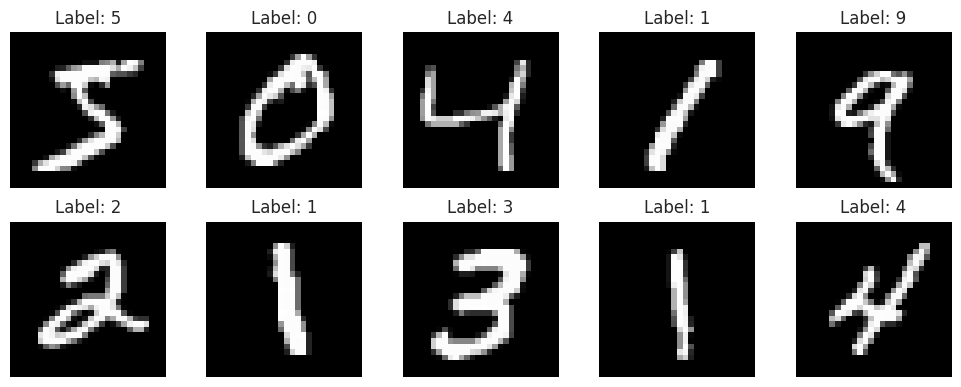

In [5]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Scale pixel values from 0-255 to 0-1

X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
model = Sequential([

    Flatten(input_shape=(28,28)),

    Dense(128, activation='relu'),

    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8151 - loss: 0.6988 - val_accuracy: 0.9022 - val_loss: 0.3366
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9102 - loss: 0.3180 - val_accuracy: 0.9240 - val_loss: 0.2687
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9252 - loss: 0.2626 - val_accuracy: 0.9321 - val_loss: 0.2337
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9345 - loss: 0.2280 - val_accuracy: 0.9419 - val_loss: 0.2060
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9426 - loss: 0.2004 - val_accuracy: 0.9479 - val_loss: 0.1875
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9488 - loss: 0.1793 - val_accuracy: 0.9519 - val_loss: 0.1703
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9545 - loss: 0.1616 - val_accuracy: 0.9543 - val_loss: 0.1626
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9578 - loss: 0.1479 - 

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", round(test_loss,4))
print("Test Accuracy:", round(test_accuracy*100,2), "%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9597 - loss: 0.1340
Test Loss: 0.134
Test Accuracy: 95.97 %


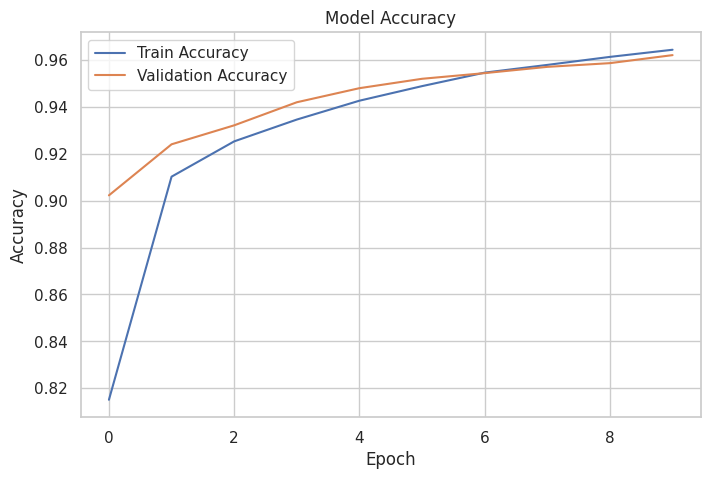

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

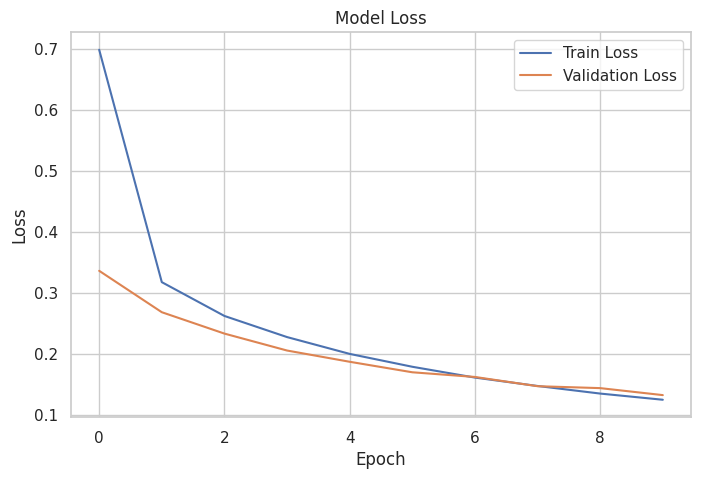

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [13]:
pred_probs = model.predict(X_test)
pred_classes = np.argmax(pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


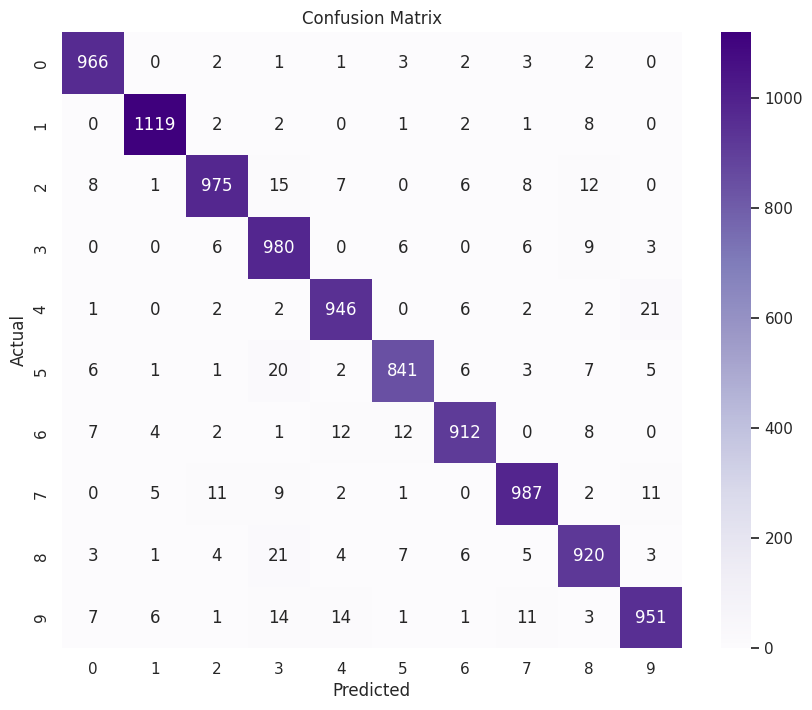

In [19]:
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.98      0.99      0.99      1135
           2       0.97      0.94      0.96      1032
           3       0.92      0.97      0.94      1010
           4       0.96      0.96      0.96       982
           5       0.96      0.94      0.95       892
           6       0.97      0.95      0.96       958
           7       0.96      0.96      0.96      1028
           8       0.95      0.94      0.95       974
           9       0.96      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



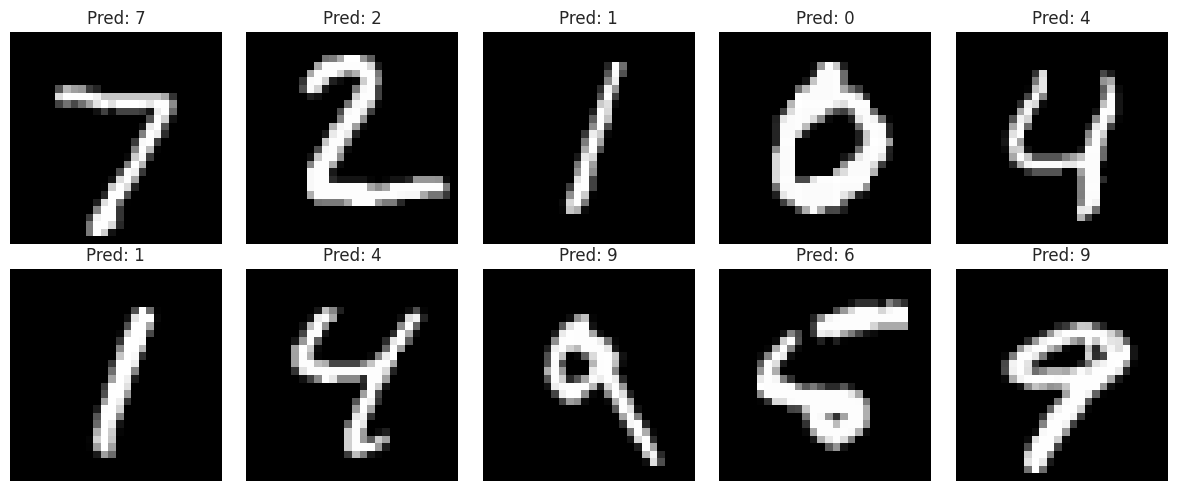

In [20]:
print(classification_report(y_test, pred_classes))
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title(f"Pred: {pred_classes[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Result Analysis

- Accuracy should reach ~95% to 98%
- Loss decreases every epoch
- Validation accuracy close to training accuracy means good generalization
- If training high but validation low → overfitting